In [24]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'


In [25]:
 
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
df_time =pd.read_csv('tables/time_maximum_BMB.csv')
# Generate loop_info DataFrame

In [26]:
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

In [27]:
models=[]
paths =[]
exps =[]
region_names = ['Amundsen','Ross','FilchnerRonne','Aurora','Wilkes']
dic_sectors ={}
dic_sectors['Amundsen']=np.array([4])
dic_sectors['Ross']=np.array([2,6])
dic_sectors['FilchnerRonne']=np.array([5,11])
dic_sectors['Aurora']=np.array([8])
dic_sectors ['Wilkes']=np.array([7])
renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
for j in range(1,4):
    df['region_'+str(j)] =0
for key in dic_sectors.keys():
    df[key] = 0
    
df_n = df.copy()
y2sec=-365.25*24*3600
factor = y2sec/10**3

In [28]:
for i in range (df.shape[0]):
    #load the datasets:
    pth_way = df.iloc[i].Path
    
    pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/iareafl/computed_iareafl_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
    if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
        nmname = renamer[df.iloc[i].Model]
    else:
            nmname = df.iloc[i].Model
    pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{nmname}_{df.iloc[i].Experiment}.nc'

    
    # Melting
    d = xr.open_dataset(pth_way,decode_times=False )
    # Area
    d2 = xr.open_dataset(pth_area,decode_times=False )
    #thermal forcing 
    d3 = xr.open_dataset(pth_tf,decode_times=False )
    
    
    ###### start with AIS
  
    t_max =  df_time.iloc[i]['AIS']
    t_max = np.min([t_max,2100])
    
    tmin =np.where( d.time.values==t_max)[0][0]
 
    #melting per area
    y= d.shelfmelt.values[:tmin]* factor/d2.iareafl.values[:tmin] #avg bmb
    x = d3.thermalforcing.values[:tmin] #thermal forcign

    if len(x)>1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        df['AIS'].iloc[i]= slope
        df_n['AIS'].iloc[i]= intercept
        
        
    else:
        df['AIS'].iloc[i]= np.nan
        df_n['AIS'].iloc[i]= np.nan
    
    #all the sectors:
    for j in range(1,19):
        t_max = df_time.iloc[i]['sector_'+str(j)]
        
        t_max = np.min([t_max,2100])
    
        tmin =np.where( d.time.values==t_max)[0][0]
 
        y =d['shelfmelt_sector_'+str(j)].values[:tmin]* factor/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcing_sector_'+str(j)].values[:tmin]
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2
    
        if len(x[~mnan])>1:
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])
        
       
            df['sector_'+str(j)].iloc[i] = slope
            df_n['sector_'+str(j)].iloc[i] = intercept
        
        else:
            df['sector_'+str(j)].iloc[i] = np.nan
            df_n['sector_'+str(j)].iloc[i] = np.nan
            
    #all the regions
    for j in range(1,4):
        t_max = df_time.iloc[i]['region_'+str(j)]
        t_max = np.min([t_max,2100])
        
    
        tmin =np.where( d.time.values==t_max)[0][0]
        y =d['shelfmelt_region_'+str(j)].values[:tmin]* factor/d2['iareafl_region_'+str(j)].values[:tmin]  #GT/m^3 yr
        x = d3['thermalforcing_region_'+str(j)].values[:tmin]

        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2


        if len(x[~mnan])>1:
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])
        
       
            df['region_'+str(j)].iloc[i] = slope
            df_n['region_'+str(j)].iloc[i] = intercept
        
        else:
            df['region_'+str(j)].iloc[i] = np.nan
            df_n['region_'+str(j)].iloc[i] = np.nan
            
    #specific region,combination of sectors: amundsen,ross, Fris
    for key in dic_sectors.keys():

        t_max = 2100
        for j in dic_sectors[key]:
            t_max1 = df_time.iloc[i]['sector_'+str(j)]
            
            t_max = np.min([t_max,t_max1])
           
            
    
        tmin =np.where( d.time.values==t_max)[0][0]
       
        #mcreat ys areas etc
        the_ys = np.zeros((len(dic_sectors[key]),tmin))
        the_areas = np.zeros((len(dic_sectors[key]),tmin))
        the_tfs = np.zeros((len(dic_sectors[key]),tmin))
   
        for k,j in enumerate(dic_sectors[key]):
            the_ys[k,:] =d['shelfmelt_sector_'+str(j)].values[:tmin].copy()* factor
            the_areas[k,:]=d2['iareafl_sector_'+str(j)].values[:tmin].copy()
            the_tfs[k,:]=d3['thermalforcing_sector_'+str(j)].values[:tmin].copy()*the_areas[k,:].copy()
        y_all = np.sum(the_ys ,axis =0)
        area = np.sum( the_areas,axis = 0)
        y = y_all.copy()/area.copy() #gives average bmb timline
            
        TF = np.sum( the_tfs,axis = 0)/area #gives average thermal foricng line
        x = TF.copy()
        mnan1 = np.isnan(y)
        mnan2 = np.isnan(x)
        mnan = mnan1 | mnan2

        if len(x[~mnan])>1:
                
            print(f'some nans!{i} at {df.iloc[i].Model}')
                
            slope, intercept, r_value, p_value, std_err = linregress(x[~mnan], y[~mnan])


            df[key].iloc[i] = slope
            df_n[key].iloc[i] = intercept
                
        else:
            print('pnli nans',df.iloc[i].Model)
            df[key].iloc[i] = np.nan
            df_n[key].iloc[i] =np.nan
                
     
            
            
            

df.to_csv('tables/linear_meltsensetivity_from_BMB_max_time2100.csv', index=False)
df_n.to_csv('tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv', index=False)

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/3179311898.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AIS'].iloc[i]= slope
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/3179311898.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n['AIS'].iloc[i]= intercept
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/3179311898.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

some nans!0 at DC_ISSM
some nans!0 at DC_ISSM
some nans!0 at DC_ISSM
some nans!0 at DC_ISSM
some nans!0 at DC_ISSM
some nans!1 at DOE_MALI_4km
some nans!1 at DOE_MALI_4km
some nans!1 at DOE_MALI_4km
some nans!1 at DOE_MALI_4km
some nans!1 at DOE_MALI_4km
some nans!2 at DOE_MALI_8km_Ant95
some nans!2 at DOE_MALI_8km_Ant95
some nans!2 at DOE_MALI_8km_Ant95
some nans!2 at DOE_MALI_8km_Ant95
some nans!2 at DOE_MALI_8km_Ant95
some nans!3 at DOE_MALI_8km_AntMean
some nans!3 at DOE_MALI_8km_AntMean
some nans!3 at DOE_MALI_8km_AntMean
some nans!3 at DOE_MALI_8km_AntMean
some nans!3 at DOE_MALI_8km_AntMean
some nans!4 at IGE_ElmerIce
some nans!4 at IGE_ElmerIce
some nans!4 at IGE_ElmerIce
some nans!4 at IGE_ElmerIce
some nans!4 at IGE_ElmerIce
some nans!5 at ILTS_SICOPOLIS
some nans!5 at ILTS_SICOPOLIS
some nans!5 at ILTS_SICOPOLIS
some nans!5 at ILTS_SICOPOLIS
some nans!5 at ILTS_SICOPOLIS
some nans!6 at IMAU_UFEMISM1
some nans!6 at IMAU_UFEMISM1
some nans!6 at IMAU_UFEMISM1
some nans!6 at IMA

some nans!56 at NCAR_CISM2
some nans!56 at NCAR_CISM2
some nans!56 at NCAR_CISM2
some nans!56 at NCAR_CISM2
some nans!56 at NCAR_CISM2
some nans!57 at NORCE_CISM2-MAR364-ERA-t1
some nans!57 at NORCE_CISM2-MAR364-ERA-t1
some nans!57 at NORCE_CISM2-MAR364-ERA-t1
some nans!57 at NORCE_CISM2-MAR364-ERA-t1
some nans!57 at NORCE_CISM2-MAR364-ERA-t1
some nans!58 at NORCE_CISM3-MAR364-ERA-t1-local
some nans!58 at NORCE_CISM3-MAR364-ERA-t1-local
some nans!58 at NORCE_CISM3-MAR364-ERA-t1-local
some nans!58 at NORCE_CISM3-MAR364-ERA-t1-local
some nans!58 at NORCE_CISM3-MAR364-ERA-t1-local
some nans!59 at NORCE_CISM3-MAR364-ERA-t1-nonlocal
some nans!59 at NORCE_CISM3-MAR364-ERA-t1-nonlocal
some nans!59 at NORCE_CISM3-MAR364-ERA-t1-nonlocal
some nans!59 at NORCE_CISM3-MAR364-ERA-t1-nonlocal
some nans!59 at NORCE_CISM3-MAR364-ERA-t1-nonlocal
some nans!60 at NORCE_CISM3-MAR364-ERA-t1
some nans!60 at NORCE_CISM3-MAR364-ERA-t1
some nans!60 at NORCE_CISM3-MAR364-ERA-t1
some nans!60 at NORCE_CISM3-MAR364

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/3179311898.py:51: RuntimeWarning: invalid value encountered in divide
  y =d['shelfmelt_sector_'+str(j)].values[:tmin]* factor/d2['iareafl_sector_'+str(j)].values[:tmin]  #GT/m^3 yr
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/3179311898.py:118: RuntimeWarning: invalid value encountered in divide
  y = y_all.copy()/area.copy() #gives average bmb timline


some nans!80 at VUW_PISM1_s4
some nans!80 at VUW_PISM1_s4
some nans!80 at VUW_PISM1_s4
some nans!80 at VUW_PISM1_s4
some nans!80 at VUW_PISM1_s4
some nans!81 at VUW_PISM2
some nans!81 at VUW_PISM2
some nans!81 at VUW_PISM2
some nans!81 at VUW_PISM2
some nans!81 at VUW_PISM2
some nans!82 at VUW_PISM2_s1
some nans!82 at VUW_PISM2_s1
some nans!82 at VUW_PISM2_s1
some nans!82 at VUW_PISM2_s1
some nans!82 at VUW_PISM2_s1
some nans!83 at VUW_PISM2_s2
some nans!83 at VUW_PISM2_s2
some nans!83 at VUW_PISM2_s2
some nans!83 at VUW_PISM2_s2
some nans!83 at VUW_PISM2_s2
some nans!84 at VUW_PISM2_s3
some nans!84 at VUW_PISM2_s3
some nans!84 at VUW_PISM2_s3
some nans!84 at VUW_PISM2_s3
some nans!84 at VUW_PISM2_s3
some nans!85 at VUW_PISM2_s4
some nans!85 at VUW_PISM2_s4
some nans!85 at VUW_PISM2_s4
some nans!85 at VUW_PISM2_s4
some nans!85 at VUW_PISM2_s4
some nans!86 at DC_ISSM
some nans!86 at DC_ISSM
some nans!86 at DC_ISSM
some nans!86 at DC_ISSM
some nans!86 at DC_ISSM
some nans!87 at DOE_MALI_

some nans!136 at IMAU_UFEMISM2
some nans!136 at IMAU_UFEMISM2
some nans!136 at IMAU_UFEMISM2
some nans!136 at IMAU_UFEMISM2
some nans!136 at IMAU_UFEMISM2
some nans!137 at IMAU_UFEMISM3
some nans!137 at IMAU_UFEMISM3
some nans!137 at IMAU_UFEMISM3
some nans!137 at IMAU_UFEMISM3
some nans!137 at IMAU_UFEMISM3
some nans!138 at IMAU_UFEMISM4
some nans!138 at IMAU_UFEMISM4
some nans!138 at IMAU_UFEMISM4
some nans!138 at IMAU_UFEMISM4
some nans!138 at IMAU_UFEMISM4
some nans!139 at LSCE_GRISLI2
some nans!139 at LSCE_GRISLI2
some nans!139 at LSCE_GRISLI2
some nans!139 at LSCE_GRISLI2
some nans!139 at LSCE_GRISLI2
some nans!140 at LSCE_GRISLI
some nans!140 at LSCE_GRISLI
some nans!140 at LSCE_GRISLI
some nans!140 at LSCE_GRISLI
some nans!140 at LSCE_GRISLI
some nans!141 at NCAR_CISM1
some nans!141 at NCAR_CISM1
some nans!141 at NCAR_CISM1
some nans!141 at NCAR_CISM1
some nans!141 at NCAR_CISM1
some nans!142 at NCAR_CISM2
some nans!142 at NCAR_CISM2
some nans!142 at NCAR_CISM2
some nans!142 at

In [29]:
#######plot the sactter tooo
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['FilchnerRonne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']

In [30]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()

In [31]:
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv')
df_ms['WestAntarctica'] = df_ms['region_1']
df_ms['EastAntarctica'] = df_ms['region_2']
df_ms['Peninsula'] = df_ms['region_3']
df_ms_n['WestAntarctica'] = df_ms_n['region_1']
df_ms_n['EastAntarctica'] = df_ms_n['region_2']
df_ms_n['Peninsula'] = df_ms_n['region_3']

df_time['WestAntarctica'] = df_time['region_1']
df_time['EastAntarctica'] = df_time['region_2']
df_time['Peninsula'] = df_time['region_3']
df_time['Aurora']=df_time['sector_8']
df_time['Wilkes']=df_time['sector_7']

In [32]:
fpath='./figs/linear_ms_until_maxBMB_time2100/'
fname='linear_ms_'
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")

variable2 = 'shelfmelt'

pth = pth_helene


variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack


pth = pth_helene

The path './figs/linear_ms_until_maxBMB_time2100/' already exists.


LSCE_GRISLI
NORCE_CISM5-MAR364-ERA-t1-local
VUW_PISM1
VUW_PISM1_s1
VUW_PISM1_s2
VUW_PISM1_s3
VUW_PISM1_s4
VUW_PISM2
VUW_PISM2_s2
VUW_PISM2_s3


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.p

VUW_PISM1_s1


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')


VUW_PISM1_s1


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_63686/442703056.py:99: RuntimeWarning: invalid value encountered in divide
  ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')


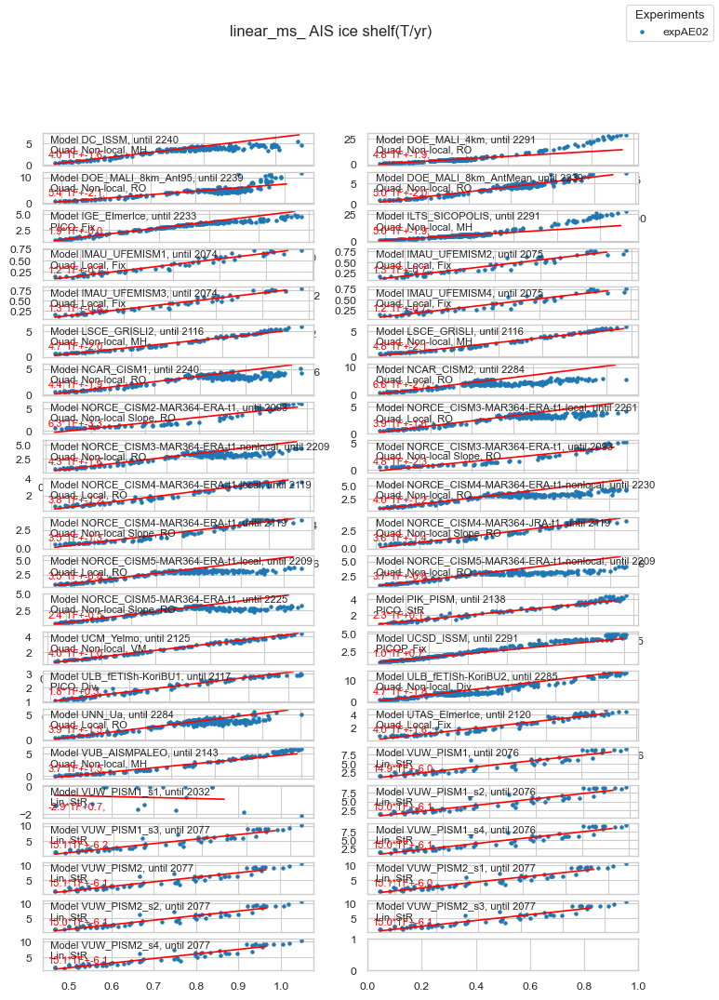

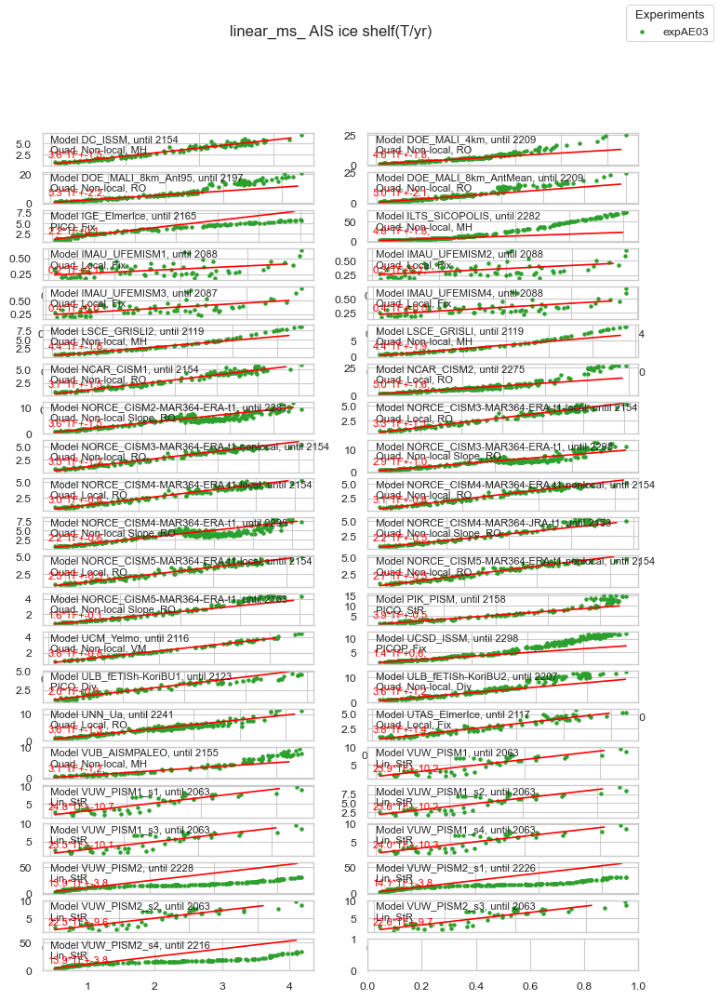

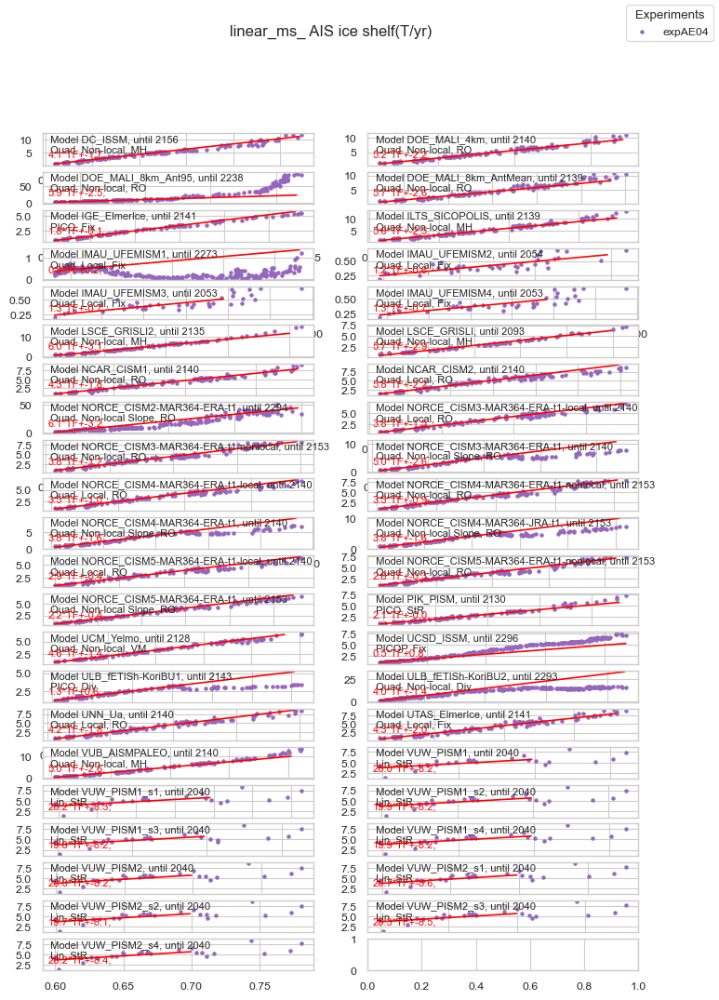

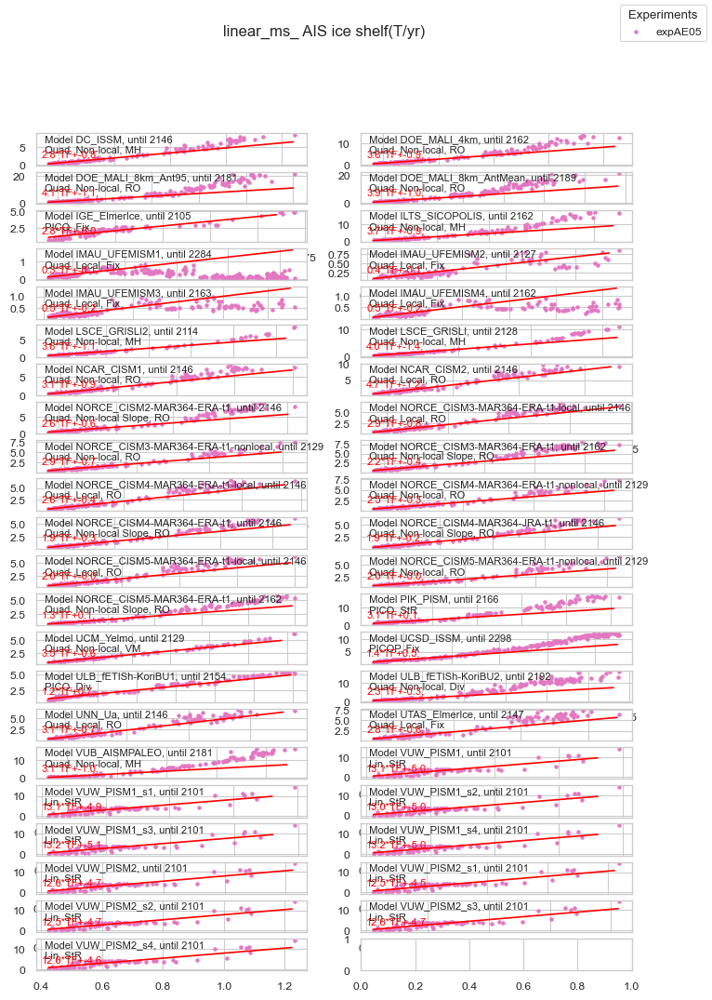

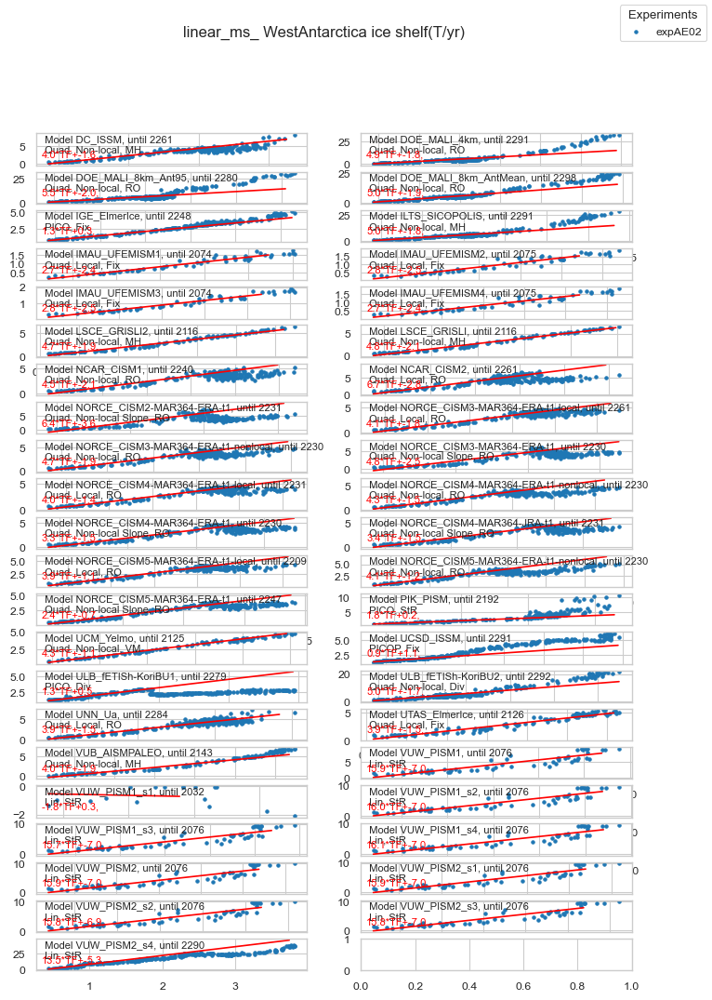

...

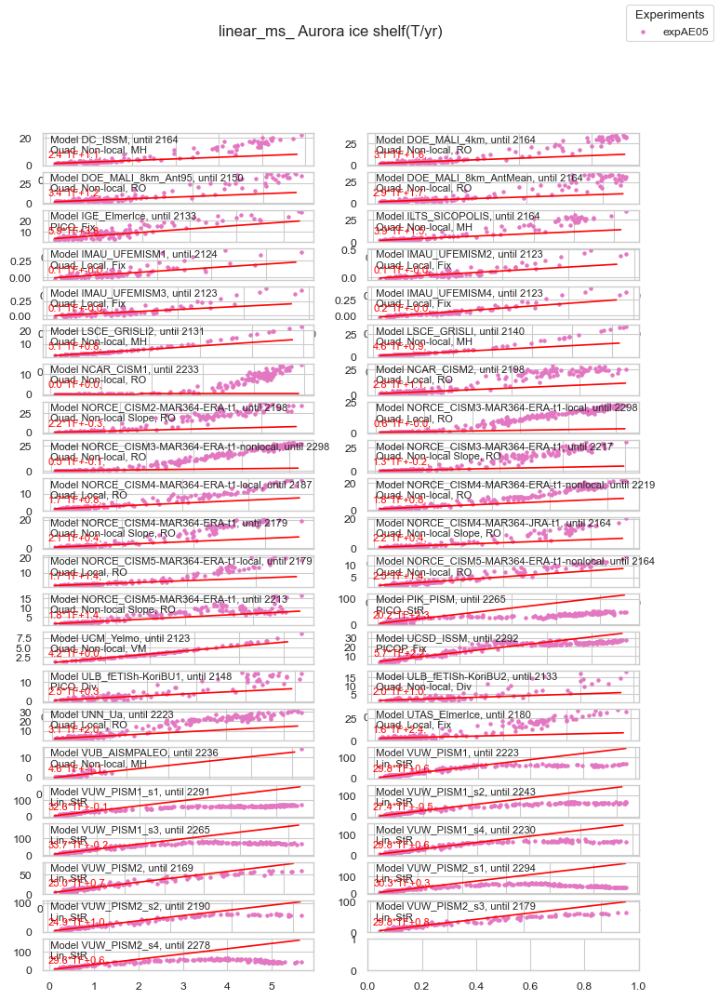

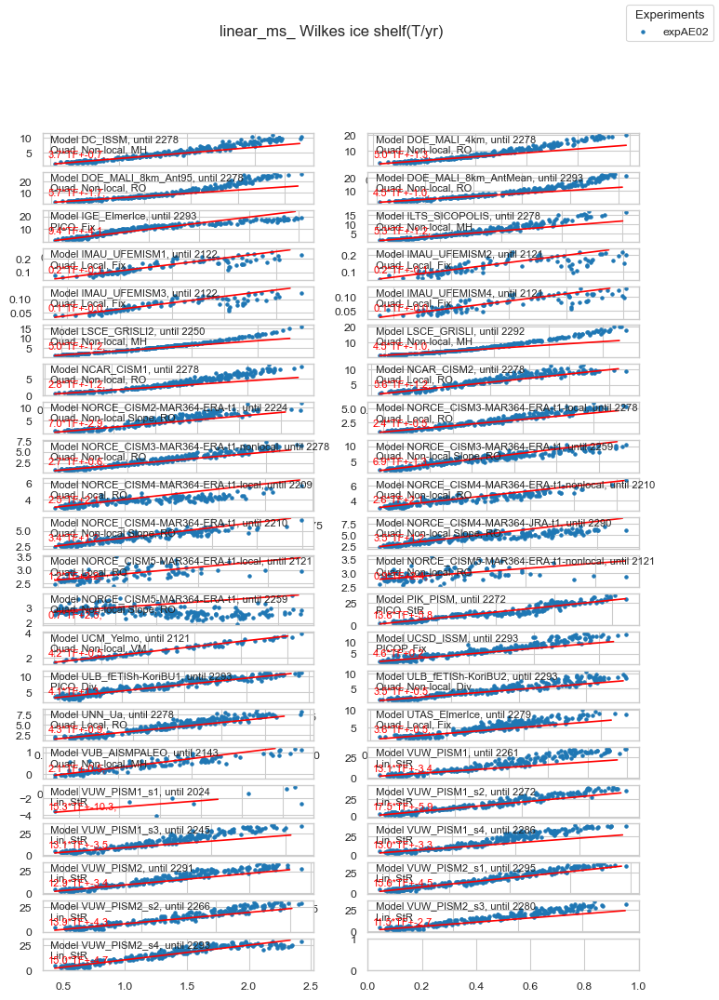

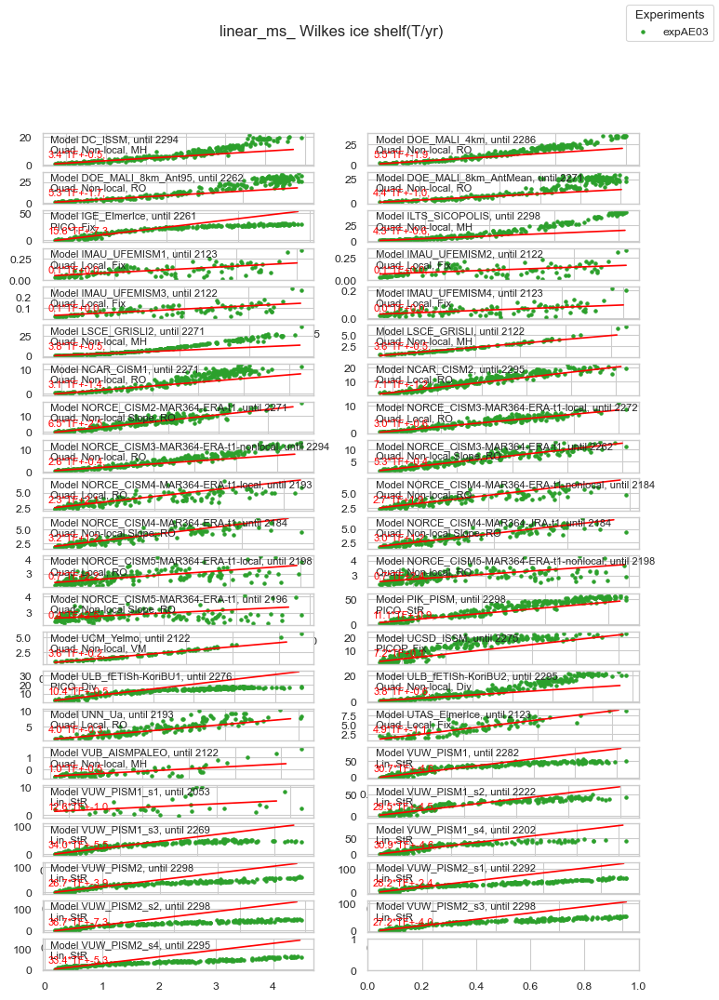

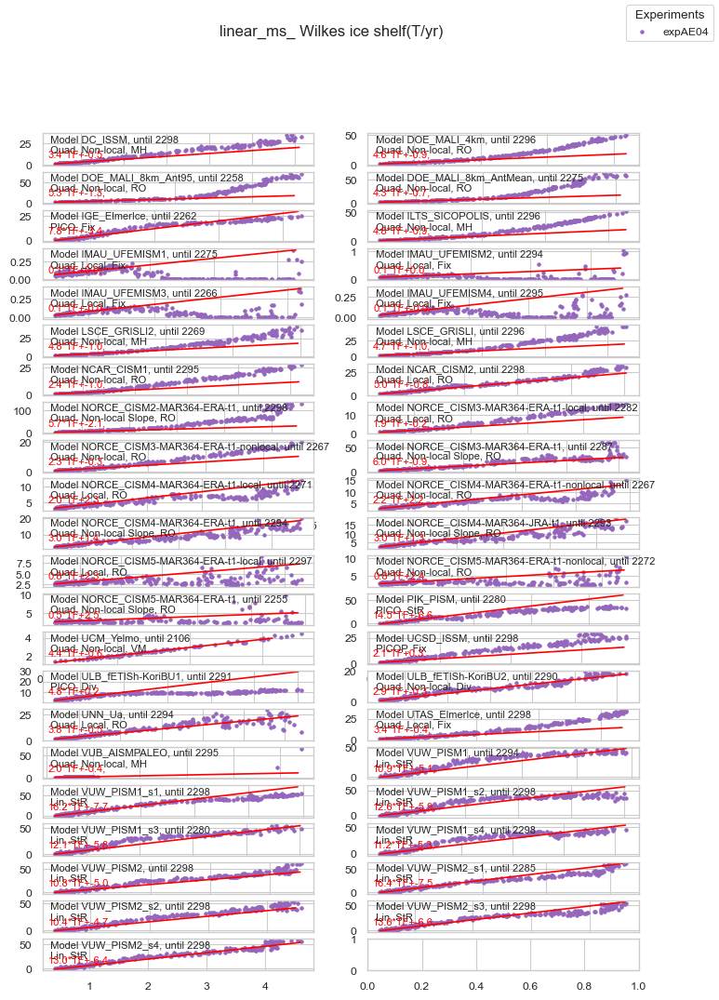

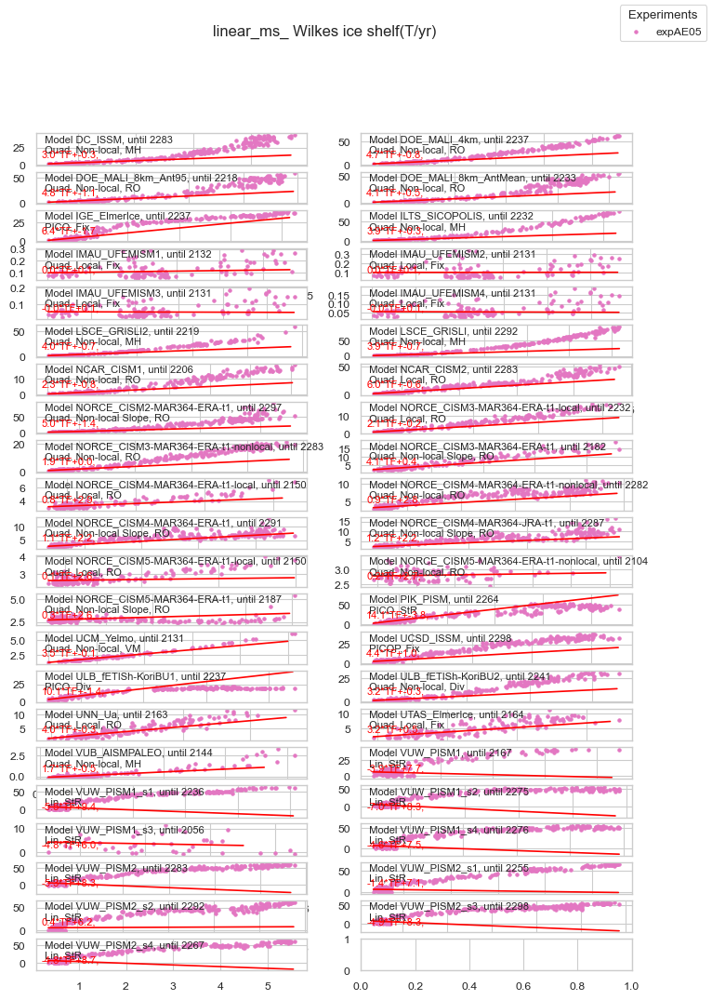

In [34]:
for key in dic_area_of_interest.keys():
# for key in ['Peninsula']:
    
  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    for j,exp in enumerate(expnames):
        f,ax = plt.subplots(df.shape[0]//2+1,2,figsize=(a4_width, a4_height))

        
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        ms_exp =df_ms[df_ms['Experiment']== exp].reset_index(drop=True)
        ms_n_exp =df_ms_n[df_ms_n['Experiment']== exp].reset_index(drop=True)
        df_time_exp = df_time[df_time['Experiment']== exp].reset_index(drop = True)

        for i in range (df.shape[0]):
   
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area

            pth_bmb = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

       
            d3 = xr.open_dataset(pth_bmb,decode_times=False )
        
            #get shelf area
            pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            d2 = xr.open_dataset(pth_area,decode_times=False )
             #thermal foring 
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
#             pth_tf = f'{pth_imip6hack}/{df.iloc[i].Experiment}/thermalforcing/computed_thermalforcing_AIS_{nmname}_{df.iloc[i].Experiment}.nc'

    
           
            pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            
          
            d4 = xr.open_dataset(pth_var3,decode_times=False )


            t_max2 = df_time_exp.iloc[i][key]
            t_max3=2298
           
            
            t_max = np.min([ t_max2 , t_max3 ])
          

    
            tmin =np.where( d.time.values>=t_max)[0][0]
       
            
            if tmin <10:
                print(df.iloc[i].Model)
            
        
             
           
           
            #melting per area
            the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
            the_areas = np.zeros((len(dic_area_of_interest[key]),tmin))
            the_tfs = np.zeros((len(dic_area_of_interest[key]),tmin))
            
            
          
            for k,nm in enumerate(lst):
             
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                the_areas[k,:]= d2[f'{variable}{nm}'].values[:tmin]
                the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:tmin]*the_areas[k,:]
                
                

            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            TF = np.sum( the_tfs,axis = 0)/area
            TF_even = np.arange(np.nanmin(TF),np.nanmax(TF),0.1)
             
            ms = ms_exp.iloc[i][key]
 
            ms_n = ms_n_exp.iloc[i][key]
            
            ax2 = ax[ix,iy]
            ax2.scatter(TF,y/area ,color = colors[j],label = f'{exp}',marker ='.')
            ax2.plot(TF_even,ms*TF_even+ms_n,color = 'red')
            
            df_info_exp = df_info[df_info['Experiment']==exp]
            
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model

            df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
#             df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
            icefront =  df_info_exp_model['ice front'].values[0]
            
            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model}, until {t_max} \n {meltparam}, {icefront}',transform=ax2.transAxes,fontsize = fs, va='top')
            ax2.text(0.02, 0.5,f'{np.round(ms,1)}*TF+{np.round(ms_n,1)},',transform=ax2.transAxes,fontsize = fs, va='top',color = 'red')
    #         ax[ix, iy].text(0.02, 0.98, f'Experiment {exp} - Model {df.iloc[i].Model}', transform=ax[ix, iy].transAxes, fontsize=12, va='top')
    
    #         f.text(0.02, 0.98,
        handles, labels = ax[0, 0].get_legend_handles_labels()
        f.legend(handles, labels, loc='upper right', title='Experiments')
     

        f.suptitle(f'{fname} {key} ice shelf(T/yr)',fontsize = 12)
        f.savefig(f'{fpath}{fname}_{key}_{exp}.pdf')
       


In [35]:
handles

In [36]:
fname

'linear_ms_'

In [37]:
key

'Wilkes'

In [38]:
f.savefig(f'{fpath}{fname}_{key}_{exp}.pdf')

In [40]:
print(f'{fpath}{fname}_{key}_{exp}.pdf')

./figs/linear_ms_until_maxBMB_time2100/linear_ms__Wilkes_expAE05.pdf
